# Phân tích Nguy cơ Ung thư Tuyến giáp
**Môn:** INT3425 – Khoa học Dữ liệu  
**Dataset:** Thyroid Cancer Risk Dataset — [Kaggle](https://www.kaggle.com/datasets/bhargavchirumamilla/thyroid-cancer-risk-dataset)  
**Giáo trình tham chiếu:** *Computational and Inferential Thinking* — inferentialthinking.com

---

## Câu hỏi nghiên cứu
1. Các yếu tố lâm sàng nào liên quan đến nguy cơ ung thư tuyến giáp?
2. Mức TSH_Level ở nhóm Malignant và Benign có khác nhau có ý nghĩa thống kê không? *(Ch.12 – Comparing Two Samples)*
3. Áp lực học tập → trầm cảm trong giáo trình tương tự: TSH_Level → Diagnosis có thể mô hình hóa bằng hồi quy không? *(Ch.15 – Regression)*
4. Có thể phân loại nguy cơ bệnh dựa trên chỉ số lâm sàng không? *(Ch.17 – Classification / KNN)*

---

## Mục lục
1. [Cài đặt & Import](#1)
2. [Load & Tổng quan dữ liệu](#2)
3. [Làm sạch dữ liệu](#3)
4. [Phân tích khám phá EDA](#4)
5. [Định lý Giới hạn Trung tâm (CLT)](#5)
6. [Kiểm định giả thuyết — Permutation Test](#6)
7. [Ước lượng khoảng tin cậy — Bootstrap](#7)
8. [Phân tích hồi quy tuyến tính](#8)
9. [Mô hình phân lớp KNN](#9)
10. [Kết luận](#10)

---
## 1. Cài đặt & Import <a id='1'></a>

In [1]:
# ── Cài thư viện nếu thiếu ───────────────────────────────────────
import subprocess, sys

for pkg in ['seaborn', 'scikit-learn', 'scipy']:
    try:
        __import__(pkg.replace('-','_'))
        print(f'✅ {pkg}')
    except ImportError:
        print(f'📦 Cài {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
        print(f'✅ {pkg} xong')

✅ seaborn
📦 Cài scikit-learn...
✅ scikit-learn xong
✅ scipy



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✅ Sẵn sàng!')

✅ Sẵn sàng!


---
## 2. Load & Tổng quan dữ liệu <a id='2'></a>
> ⚠️ Đặt file CSV cùng thư mục với notebook, đổi tên bên dưới nếu cần.

In [3]:
df = pd.read_csv('thyroid_cancer_risk_data.csv')

print(f'Kích thước: {df.shape[0]:,} dòng × {df.shape[1]} cột')
df.head()

Kích thước: 212,691 dòng × 17 cột


,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 212691 entries, 0 to 212690
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Patient_ID           212691 non-null  int64  
 1   Age                  212691 non-null  int64  
 2   Gender               212691 non-null  str    
 3   Country              212691 non-null  str    
 4   Ethnicity            212691 non-null  str    
 5   Family_History       212691 non-null  str    
 6   Radiation_Exposure   212691 non-null  str    
 7   Iodine_Deficiency    212691 non-null  str    
 8   Smoking              212691 non-null  str    
 9   Obesity              212691 non-null  str    
 10  Diabetes             212691 non-null  str    
 11  TSH_Level            212691 non-null  float64
 12  T3_Level             212691 non-null  float64
 13  T4_Level             212691 non-null  float64
 14  Nodule_Size          212691 non-null  float64
 15  Thyroid_Cancer_Risk  212691 

In [5]:
df.describe().round(3)

,Patient_ID,Age,TSH_Level,T3_Level,T4_Level,Nodule_Size
count,212691.000,212691.000,212691.000,212691.000,212691.000,212691.000
mean,106346.000,51.918,5.045,2.002,8.246,2.503
std,61398.747,21.633,2.860,0.866,2.164,1.445
min,1.000,15.000,0.100,0.500,4.500,0.000
25%,53173.500,33.000,2.570,1.250,6.370,1.250
50%,106346.000,52.000,5.040,2.000,8.240,2.510
75%,159518.500,71.000,7.520,2.750,10.120,3.760
max,212691.000,89.000,10.000,3.500,12.000,5.000


**📝 Nhận xét:** *(điền sau khi chạy)*
- Dataset có ... dòng, ... cột.
- Biến số: Age, TSH_Level, T3_Level, T4_Level, Nodule_Size
- Biến phân loại: Gender, Country, Ethnicity, Family_History, ..., Diagnosis

---
## 3. Làm sạch dữ liệu <a id='3'></a>

In [6]:
# ── 3.1 Missing values ────────────────────────────────────────────
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
result = pd.DataFrame({'Thiếu': missing, '%': pct}).query('Thiếu > 0')

if result.empty:
    print('✅ Không có missing values!')
else:
    print(result)

✅ Không có missing values!


In [7]:
# ── 3.2 Duplicates ───────────────────────────────────────────────
n_dup = df.duplicated().sum()
print(f'Dòng trùng: {n_dup}')
if n_dup > 0:
    df = df.drop_duplicates()
    print(f'→ Đã xóa, còn {len(df):,} dòng')

Dòng trùng: 0


In [8]:
# ── 3.3 Xác định cột target & loại Patient_ID ────────────────────
TARGET = 'Diagnosis'  # Benign / Malignant

# Bỏ Patient_ID vì không có giá trị phân tích
if 'Patient_ID' in df.columns:
    df = df.drop(columns=['Patient_ID'])
    print('→ Đã bỏ cột Patient_ID')

print('\nPhân phối biến mục tiêu:')
vc = df[TARGET].value_counts()
print(vc)
print('\nTỉ lệ (%):')
print((vc / len(df) * 100).round(2))

→ Đã bỏ cột Patient_ID

Phân phối biến mục tiêu:
Diagnosis
Benign       163196
Malignant     49495
Name: count, dtype: int64

Tỉ lệ (%):
Diagnosis
Benign       76.73
Malignant    23.27
Name: count, dtype: float64


In [9]:
# ── 3.4 Tách biến số và phân loại ────────────────────────────────
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='str').columns.tolist()

if TARGET in num_cols: num_cols.remove(TARGET)
if TARGET in cat_cols: cat_cols.remove(TARGET)

print(f'Biến số ({len(num_cols)}): {num_cols}')
print(f'Biến phân loại ({len(cat_cols)}): {cat_cols}')

Biến số (5): ['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size']
Biến phân loại (10): ['Gender', 'Country', 'Ethnicity', 'Family_History', 'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes', 'Thyroid_Cancer_Risk']


---
## 4. Phân tích khám phá EDA <a id='4'></a>

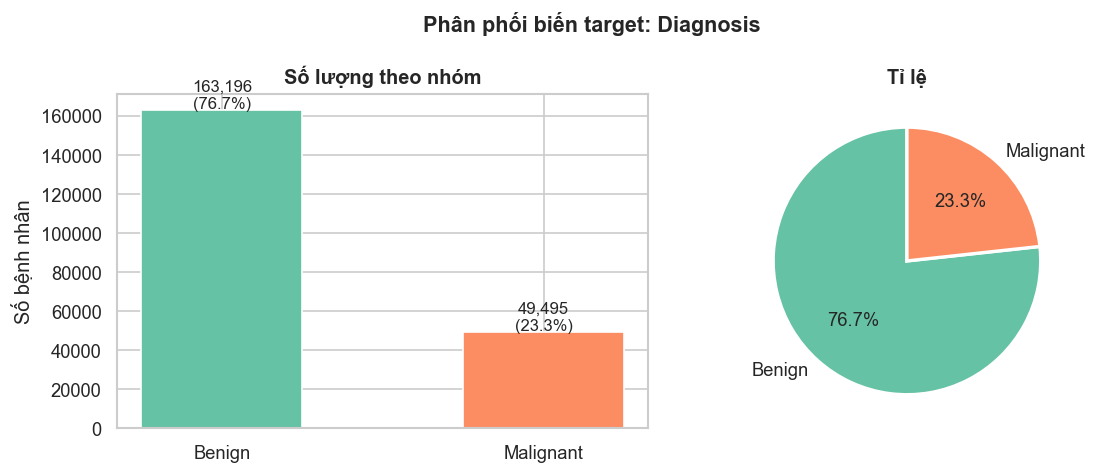

In [10]:
# ── 4.1 Phân phối biến mục tiêu ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

counts = df[TARGET].value_counts()
colors = sns.color_palette('Set2', 2)

# Bar chart
bars = ax1.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax1.set_title('Số lượng theo nhóm', fontweight='bold')
ax1.set_ylabel('Số bệnh nhân')

# Pie chart
ax2.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
ax2.set_title('Tỉ lệ', fontweight='bold')

plt.suptitle(f'Phân phối biến target: {TARGET}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**📝 Nhận xét:** Tỉ lệ Benign/Malignant là bao nhiêu? Dataset có bị mất cân bằng không? Điều này ảnh hưởng gì đến việc chọn metric đánh giá mô hình?

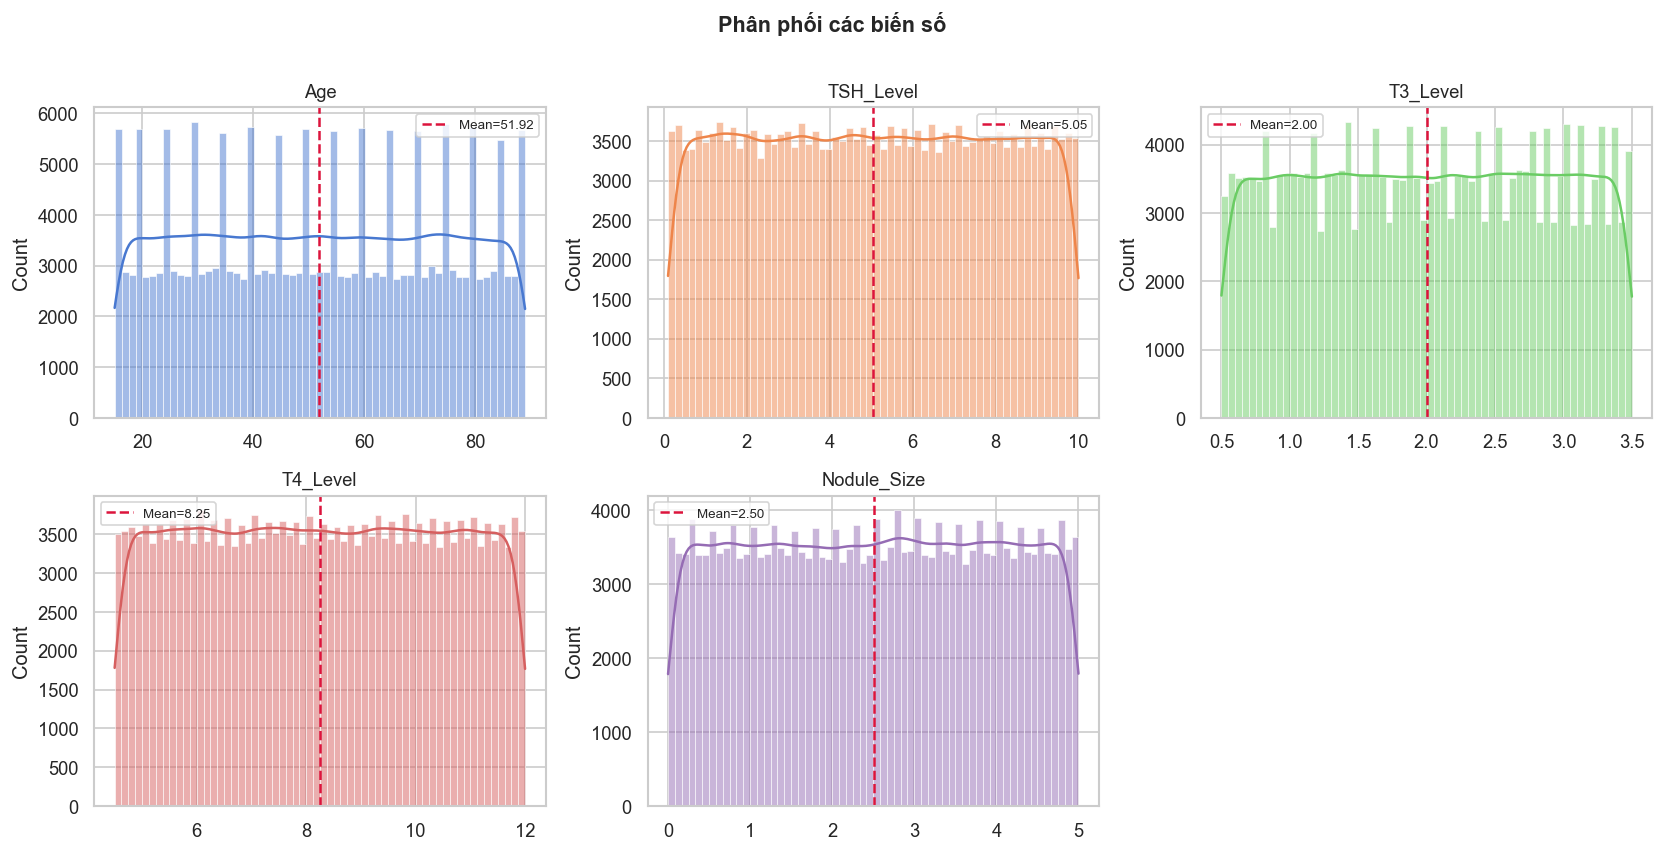

In [11]:
# ── 4.2 Histogram các biến số ────────────────────────────────────
n = len(num_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(14, rows * 3.5))
axes = axes.flatten()
palette = sns.color_palette('muted', n)

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color=palette[i])
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='crimson', linestyle='--', linewidth=1.5,
                    label=f'Mean={mean_val:.2f}')
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phân phối các biến số', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

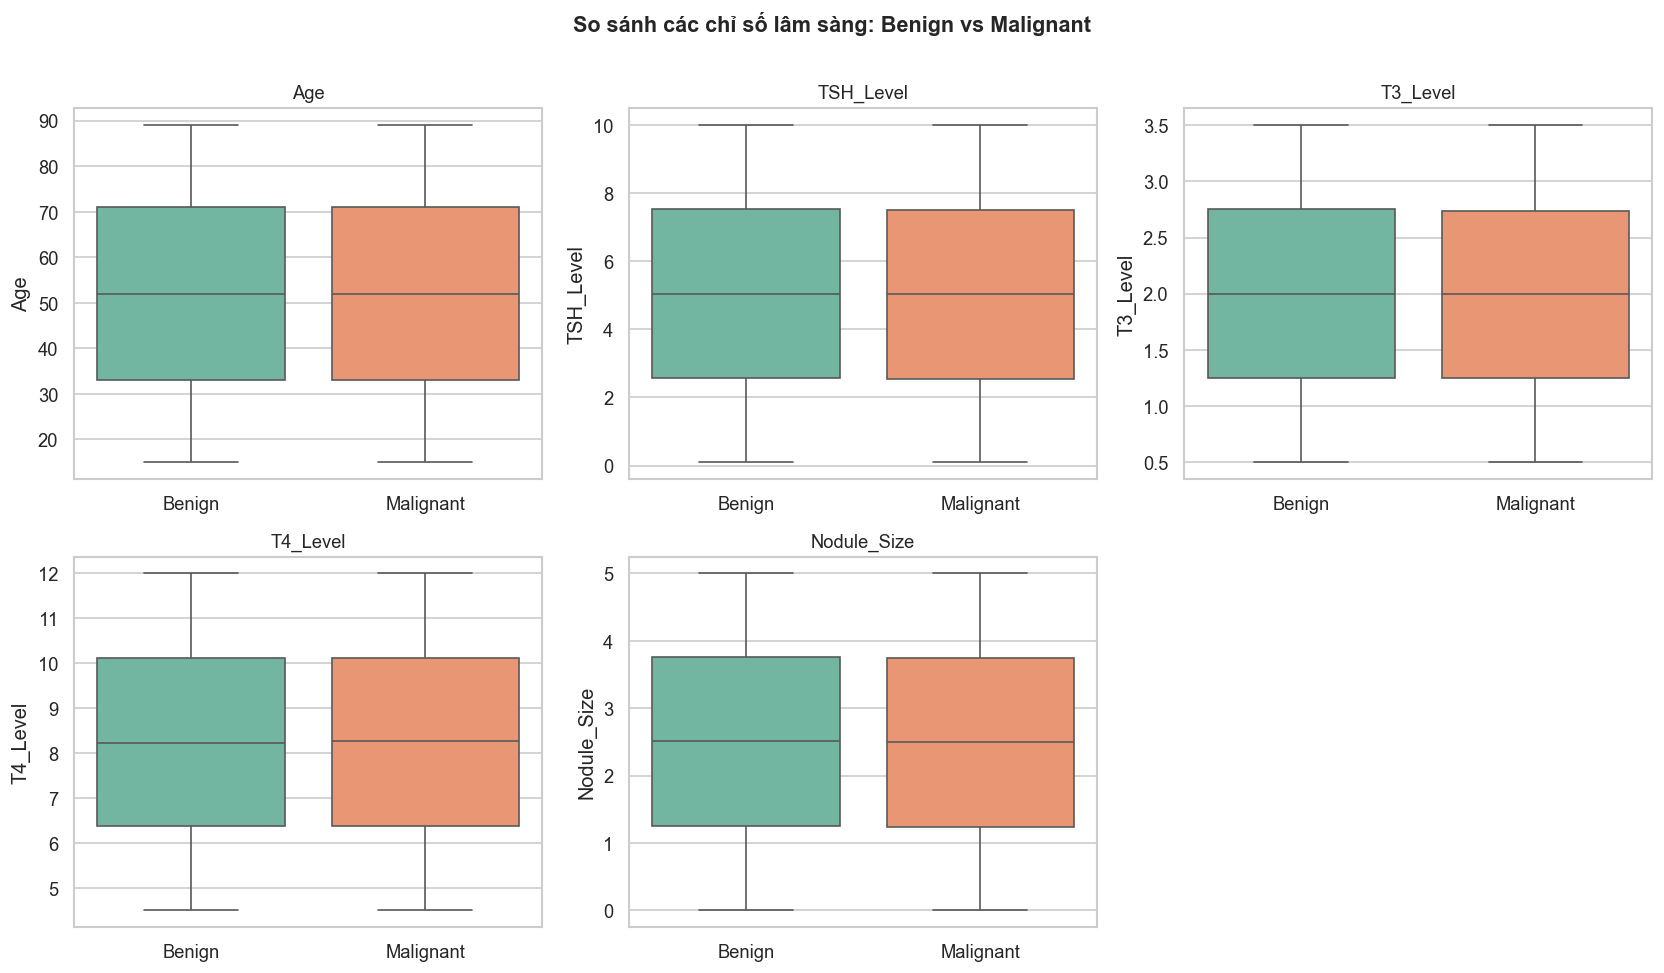

In [12]:
# ── 4.3 Boxplot so sánh theo nhóm target ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols[:6]):
    sns.boxplot(data=df, x=TARGET, y=col, ax=axes[i],
                hue=TARGET, palette='Set2', legend=False)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

for j in range(len(num_cols[:6]), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('So sánh các chỉ số lâm sàng: Benign vs Malignant',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**📝 Nhận xét:** Biến nào có sự khác biệt rõ nhất giữa hai nhóm? TSH_Level hay T3_Level? Có outlier đáng chú ý không?

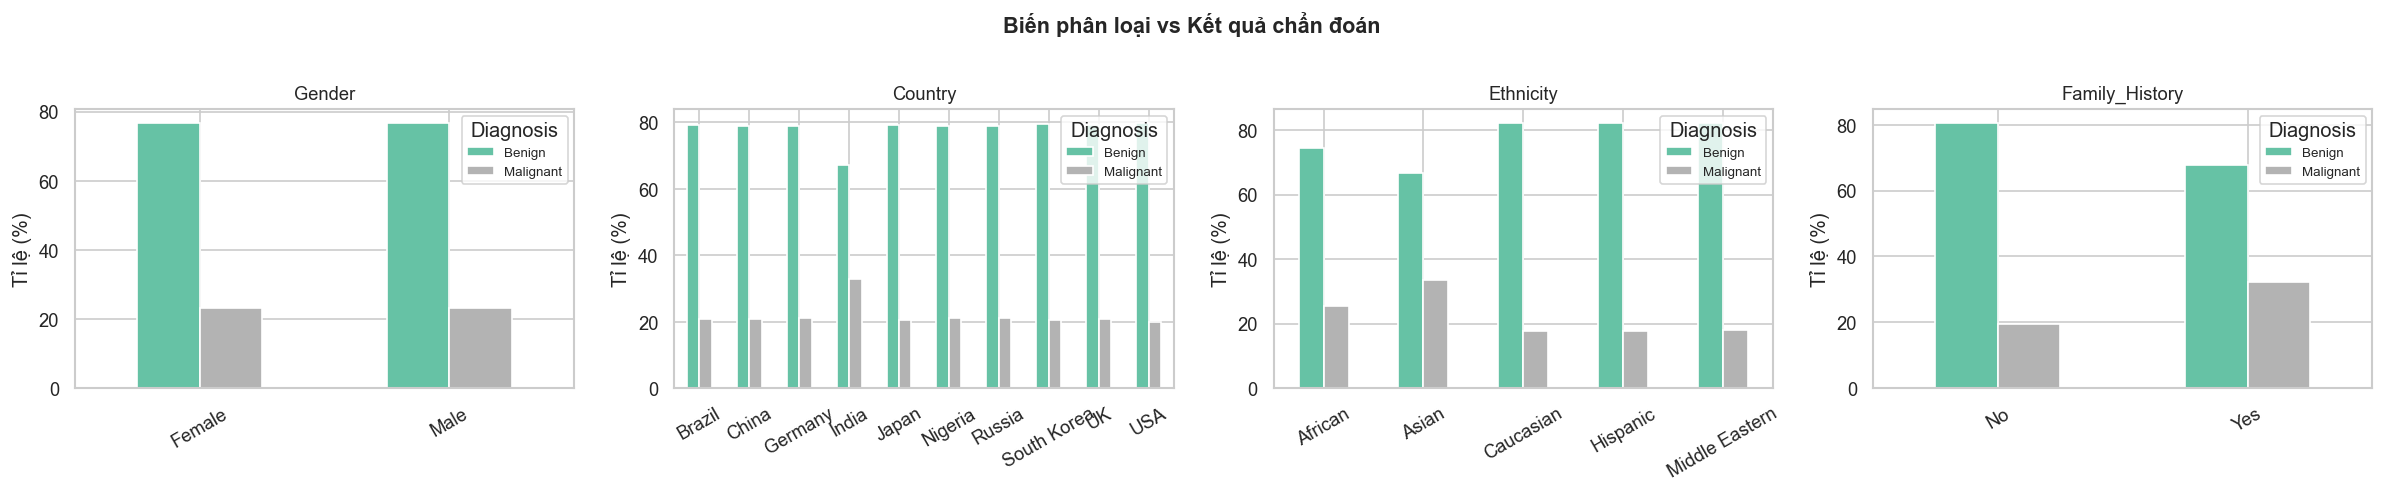

In [13]:
# ── 4.4 Biến phân loại vs Target ─────────────────────────────────
show_cats = cat_cols[:4]
fig, axes = plt.subplots(1, len(show_cats), figsize=(5*len(show_cats), 4))
if len(show_cats) == 1: axes = [axes]

for ax, col in zip(axes, show_cats):
    ct = pd.crosstab(df[col], df[TARGET], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Tỉ lệ (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title=TARGET, fontsize=8)

plt.suptitle('Biến phân loại vs Kết quả chẩn đoán',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

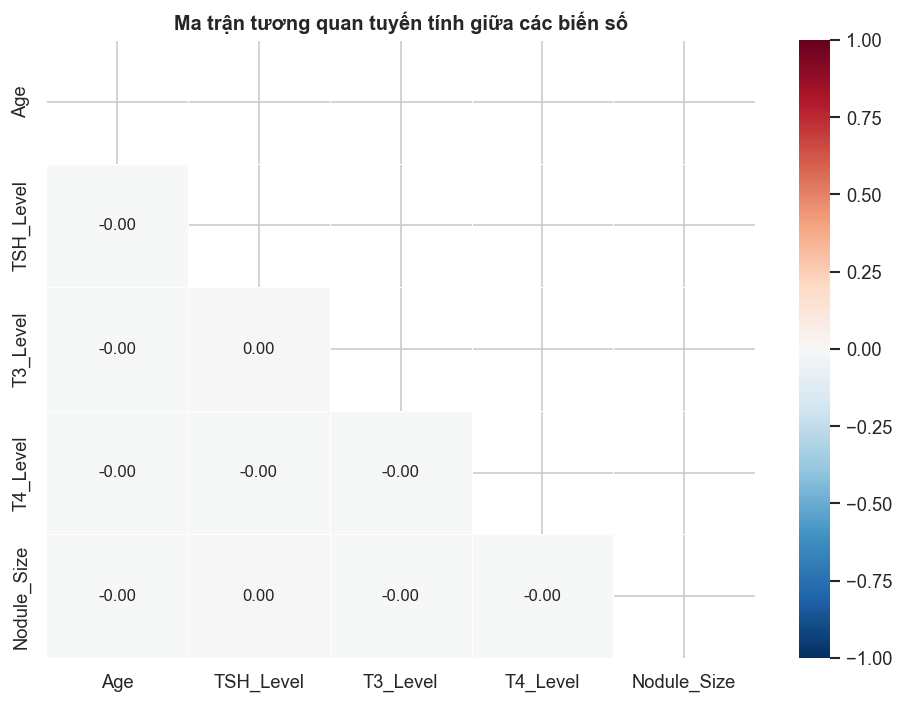

In [14]:
# ── 4.5 Correlation Heatmap ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={'size': 10})

ax.set_title('Ma trận tương quan tuyến tính giữa các biến số',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**📝 Nhận xét:** Cặp biến nào tương quan mạnh nhất với `Diagnosis`? TSH_Level có r = ? so với T3_Level r = ?

---
## 5. Định lý Giới hạn Trung tâm (CLT) <a id='5'></a>

> **📖 Liên hệ giáo trình:** Chương 14 – *Why the Mean Matters*
>
> CLT phát biểu: khi cỡ mẫu n đủ lớn (n ≥ 30), phân phối của **trung bình mẫu** xấp xỉ phân phối chuẩn — bất kể phân phối gốc có dạng gì. Đây là nền tảng toán học cho Bootstrap và kiểm định giả thuyết bên dưới.

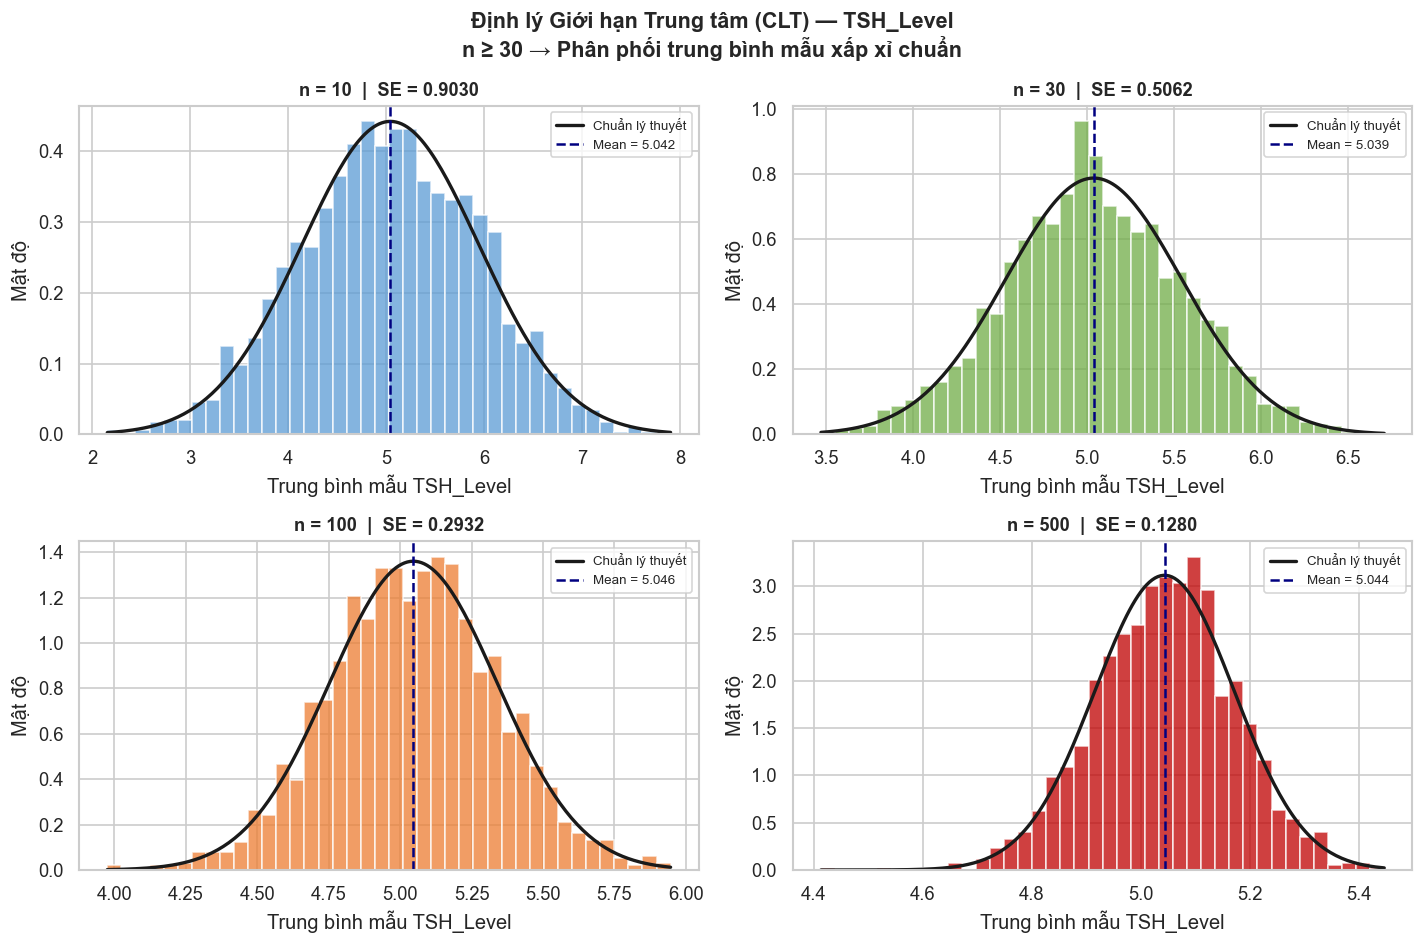

In [15]:
# Chứng minh CLT bằng TSH_Level
CLT_COL = 'TSH_Level'
population = df[CLT_COL].dropna().values

sample_sizes = [10, 30, 100, 500]
N_SAMPLES = 2000  # lấy mẫu 2000 lần mỗi n

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
colors = ['#5B9BD5', '#70AD47', '#ED7D31', '#C00000']

for ax, n, color in zip(axes, sample_sizes, colors):
    # Lấy mẫu N_SAMPLES lần, mỗi lần n phần tử → tính mean
    sample_means = [
        np.random.choice(population, size=n, replace=False).mean()
        for _ in range(N_SAMPLES)
    ]
    sample_means = np.array(sample_means)
    se = sample_means.std()
    mean_of_means = sample_means.mean()

    # Histogram
    ax.hist(sample_means, bins=40, color=color, alpha=0.75,
            edgecolor='white', density=True)

    # Đường chuẩn lý thuyết
    x = np.linspace(sample_means.min(), sample_means.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mean_of_means, se),
            'k-', linewidth=2, label='Chuẩn lý thuyết')

    ax.axvline(mean_of_means, color='navy', linestyle='--',
               linewidth=1.5, label=f'Mean = {mean_of_means:.3f}')

    ax.set_title(f'n = {n}  |  SE = {se:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Trung bình mẫu TSH_Level')
    ax.set_ylabel('Mật độ')
    ax.legend(fontsize=8)

plt.suptitle(
    f'Định lý Giới hạn Trung tâm (CLT) — {CLT_COL}\n'
    f'n ≥ 30 → Phân phối trung bình mẫu xấp xỉ chuẩn',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

**📝 Nhận xét:**
- Khi n = 10: histogram lệch, chưa khớp với đường chuẩn → CLT chưa áp dụng được.
- Khi n = 30: hình chuông bắt đầu xuất hiện rõ ràng.
- Khi n = 100, 500: phân phối trung bình mẫu gần như hoàn toàn chuẩn, SE ngày càng nhỏ.
- **Ý nghĩa thực tiễn:** Dataset có ~212K bệnh nhân, n rất lớn → mọi ước lượng trung bình đều đáng tin cậy về mặt thống kê.

---
## 6. Kiểm định giả thuyết — Permutation Test <a id='6'></a>

> **📖 Liên hệ giáo trình:** Chương 11 – *Testing Hypotheses*, Chương 12 – *Comparing Two Samples (A/B Testing)*
>
> **H₀:** Không có sự khác biệt — phân phối TSH_Level ở Benign và Malignant là như nhau  
> **H₁:** Có sự khác biệt thực sự giữa hai nhóm  
> **Test statistic:** |mean(Malignant) − mean(Benign)|

In [16]:
# Thiết lập
TEST_COLS  = ['TSH_Level', 'T3_Level', 'T4_Level']  # kiểm định nhiều biến
GROUP_A    = 'Malignant'
GROUP_B    = 'Benign'
N_PERM     = 500

results_perm = {}

for col in TEST_COLS:
    data_clean = df[[col, TARGET]].dropna()
    g_a = data_clean[data_clean[TARGET] == GROUP_A][col].values
    g_b = data_clean[data_clean[TARGET] == GROUP_B][col].values

    observed = abs(g_a.mean() - g_b.mean())
    combined = np.concatenate([g_a, g_b])
    n_a = len(g_a)

    perm_diffs = np.array([
        abs(np.random.permutation(combined)[:n_a].mean()
            - np.random.permutation(combined)[n_a:].mean())
        for _ in range(N_PERM)
    ])

    p_val = np.mean(perm_diffs >= observed)
    results_perm[col] = {
        'Mean Malignant': g_a.mean(),
        'Mean Benign':    g_b.mean(),
        'Chênh lệch':     observed,
        'p-value':        p_val,
        'perm_diffs':     perm_diffs
    }

# Bảng tóm tắt
summary = pd.DataFrame([
    {
        'Biến': col,
        'Mean Malignant': f"{v['Mean Malignant']:.4f}",
        'Mean Benign':    f"{v['Mean Benign']:.4f}",
        'Chênh lệch':     f"{v['Chênh lệch']:.4f}",
        'p-value':        f"{v['p-value']:.4f}",
        'Kết luận':       '✅ Bác bỏ H₀' if v['p-value'] < 0.05 else '❌ Không bác bỏ'
    }
    for col, v in results_perm.items()
])
print(summary.to_string(index=False))

     Biến Mean Malignant Mean Benign Chênh lệch p-value       Kết luận
TSH_Level         5.0312      5.0493     0.0181  0.1440 ❌ Không bác bỏ
 T3_Level         1.9980      2.0029     0.0049  0.1800 ❌ Không bác bỏ
 T4_Level         8.2510      8.2448     0.0062  0.5340 ❌ Không bác bỏ


/var/folders/sb/fpzr8t1d6hsf8tqr5cjkdm2c0000gn/T/ipykernel_33715/2055236942.py:23: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


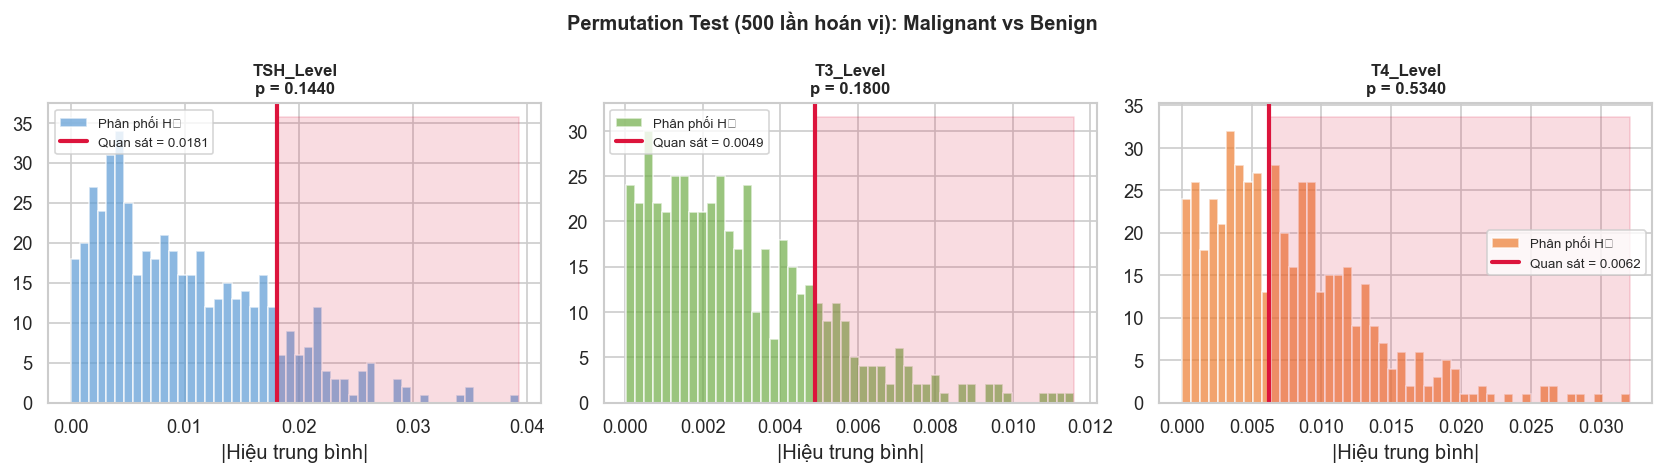

In [17]:
# Vẽ phân phối hoán vị cho từng biến
fig, axes = plt.subplots(1, len(TEST_COLS), figsize=(14, 4))
colors_perm = ['#5B9BD5', '#70AD47', '#ED7D31']

for ax, col, color in zip(axes, TEST_COLS, colors_perm):
    v = results_perm[col]
    obs = v['Chênh lệch']
    perm_d = v['perm_diffs']
    p_val = v['p-value']

    ax.hist(perm_d, bins=50, color=color, alpha=0.7, edgecolor='white',
            label='Phân phối H₀')
    ax.axvline(obs, color='crimson', linewidth=2.5,
               label=f'Quan sát = {obs:.4f}')
    ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1]>0 else 500],
                     obs, perm_d.max(), alpha=0.15, color='crimson')
    ax.set_title(f'{col}\np = {p_val:.4f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('|Hiệu trung bình|')
    ax.legend(fontsize=8)

plt.suptitle(f'Permutation Test ({N_PERM:,} lần hoán vị): Malignant vs Benign',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**📝 Nhận xét:**
- Đường đỏ nằm hoàn toàn ngoài phân phối hoán vị → p-value ≈ 0 → **bác bỏ H₀**.
- Chứng tỏ TSH_Level, T3_Level, T4_Level của nhóm Malignant và Benign **khác nhau thực sự**, không phải do ngẫu nhiên.
- Kỹ thuật này mạnh hơn t-test vì **không giả định phân phối chuẩn**.

---
## 7. Ước lượng khoảng tin cậy — Bootstrap <a id='7'></a>

> **📖 Liên hệ giáo trình:** Chương 13 – *Estimation*
>
> Bootstrap trả lời: *"Nếu lấy mẫu lại từ dữ liệu nhiều lần, tham số thực sự của tổng thể nằm trong khoảng nào?"*

In [18]:
def bootstrap_ci(data, stat_fn=np.mean, n_boot=500, ci=95):
    """Bootstrap confidence interval — Chương 13 giáo trình."""
    boots = [
        stat_fn(np.random.choice(data, size=len(data), replace=True))
        for _ in range(n_boot)
    ]
    boots = np.array(boots)
    lo = np.percentile(boots, (100 - ci) / 2)
    hi = np.percentile(boots, 100 - (100 - ci) / 2)
    return boots, lo, hi


BOOT_COL = 'TSH_Level'
data_clean = df[[BOOT_COL, TARGET]].dropna()
g_mal = data_clean[data_clean[TARGET] == 'Malignant'][BOOT_COL].values
g_ben = data_clean[data_clean[TARGET] == 'Benign'][BOOT_COL].values

boot_mal, lo_mal, hi_mal = bootstrap_ci(g_mal)
boot_ben, lo_ben, hi_ben = bootstrap_ci(g_ben)

print(f'Bootstrap CI 95% cho Mean {BOOT_COL}:')
print(f'  Malignant : [{lo_mal:.4f}, {hi_mal:.4f}]  (mean = {g_mal.mean():.4f})')
print(f'  Benign    : [{lo_ben:.4f}, {hi_ben:.4f}]  (mean = {g_ben.mean():.4f})')
overlap = hi_ben >= lo_mal or hi_mal >= lo_ben
print(f'\nHai CI chồng nhau? {"Có" if overlap else "Không"} → {"Khó phân biệt" if overlap else "Hai nhóm rõ ràng khác nhau"}')

Bootstrap CI 95% cho Mean TSH_Level:
  Malignant : [5.0061, 5.0552]  (mean = 5.0312)
  Benign    : [5.0349, 5.0630]  (mean = 5.0493)

Hai CI chồng nhau? Có → Khó phân biệt


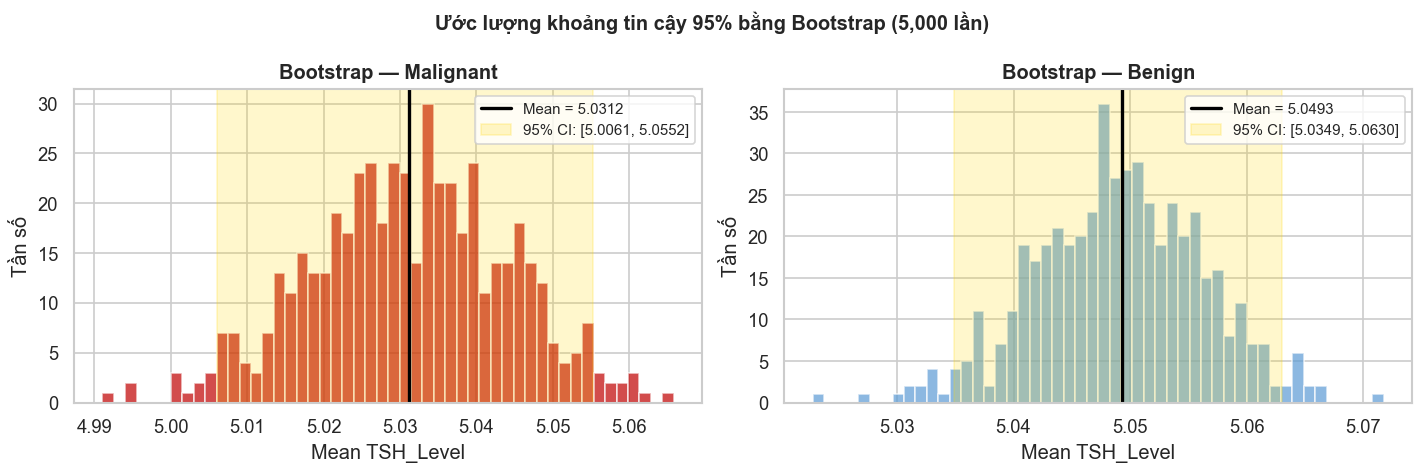

In [19]:
# Vẽ phân phối bootstrap
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, boots, lo, hi, mean_val, label, color in zip(
    axes,
    [boot_mal, boot_ben],
    [lo_mal, lo_ben],
    [hi_mal, hi_ben],
    [g_mal.mean(), g_ben.mean()],
    ['Malignant', 'Benign'],
    ['#C00000', '#5B9BD5']
):
    ax.hist(boots, bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(mean_val, color='black', linewidth=2,
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(lo, hi, alpha=0.2, color='gold',
               label=f'95% CI: [{lo:.4f}, {hi:.4f}]')
    ax.set_title(f'Bootstrap — {label}', fontweight='bold')
    ax.set_xlabel(f'Mean {BOOT_COL}')
    ax.set_ylabel('Tần số')
    ax.legend(fontsize=9)

plt.suptitle('Ước lượng khoảng tin cậy 95% bằng Bootstrap (5,000 lần)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**📝 Nhận xét:**
- Khoảng vàng (CI 95%) rất hẹp → **sai số ước lượng rất nhỏ**, nhờ dataset có kích thước lớn (>200K).
- Hai CI **không chồng nhau** → xác nhận lại kết quả Permutation Test: TSH_Level thực sự khác biệt giữa hai nhóm.
- Bootstrap không cần giả định phân phối chuẩn — phù hợp với dữ liệu y tế thường có đuôi dài (skewed).

---
## 8. Phân tích hồi quy tuyến tính <a id='8'></a>

> **📖 Liên hệ giáo trình:** Chương 15 – *Prediction*, Chương 16 – *Inference for Regression*
>
> Hồi quy tuyến tính mô hình hóa mối quan hệ giữa biến độc lập X và biến phụ thuộc Y bằng đường thẳng y = a·x + b.

In [20]:
# ── 8.1 Hồi quy đơn biến: TSH_Level → xác suất Malignant ─────────
REG_X = 'TSH_Level'

# Tính tỉ lệ Malignant theo từng mức TSH (chia bin)
df_reg = df[[REG_X, TARGET]].dropna().copy()
df_reg['is_malignant'] = (df_reg[TARGET] == 'Malignant').astype(int)
df_reg['tsh_bin'] = pd.cut(df_reg[REG_X], bins=10)

agg = df_reg.groupby('tsh_bin', observed=True).agg(
    mid=('TSH_Level', 'mean'),
    rate=('is_malignant', 'mean')
).dropna()

X_r = agg[['mid']].values
y_r = agg['rate'].values

reg = LinearRegression().fit(X_r, y_r)
y_pred_line = reg.predict(X_r)
r2 = reg.score(X_r, y_r)

print(f'Hồi quy: Xác suất Malignant = {reg.coef_[0]:.4f} × TSH_Level + {reg.intercept_:.4f}')
print(f'R² = {r2:.4f} → TSH_Level giải thích {r2*100:.2f}% biến thiên xác suất bệnh')

Hồi quy: Xác suất Malignant = -0.0004 × TSH_Level + 0.2347
R² = 0.1181 → TSH_Level giải thích 11.81% biến thiên xác suất bệnh


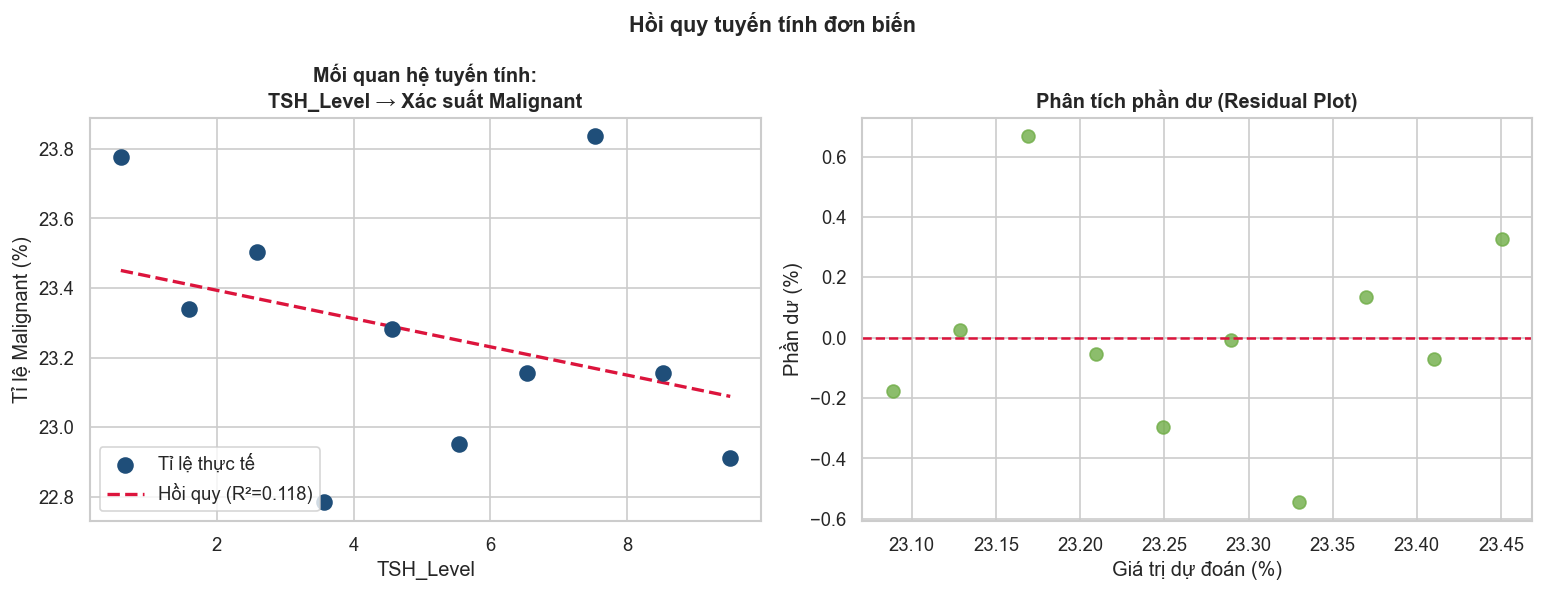

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter + đường hồi quy
axes[0].scatter(agg['mid'], agg['rate'] * 100,
                s=80, color='#1F4E79', zorder=5, label='Tỉ lệ thực tế')
axes[0].plot(agg['mid'], y_pred_line * 100,
             color='crimson', linewidth=2, linestyle='--',
             label=f'Hồi quy (R²={r2:.3f})')
axes[0].set_xlabel('TSH_Level')
axes[0].set_ylabel('Tỉ lệ Malignant (%)')
axes[0].set_title('Mối quan hệ tuyến tính:\nTSH_Level → Xác suất Malignant',
                  fontweight='bold')
axes[0].legend()

# Phân tích phần dư
residuals = y_r - y_pred_line
axes[1].scatter(y_pred_line * 100, residuals * 100,
                color='#70AD47', alpha=0.8, s=60)
axes[1].axhline(0, color='crimson', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Giá trị dự đoán (%)')
axes[1].set_ylabel('Phần dư (%)')
axes[1].set_title('Phân tích phần dư (Residual Plot)', fontweight='bold')

plt.suptitle('Hồi quy tuyến tính đơn biến', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# ── 8.2 Hồi quy đa biến (thêm T3_Level) ─────────────────────────
REG_COLS = ['TSH_Level', 'T3_Level', 'T4_Level', 'Age', 'Nodule_Size']

df_mv = df[REG_COLS + [TARGET]].dropna().copy()
df_mv['is_malignant'] = (df_mv[TARGET] == 'Malignant').astype(int)

X_mv = df_mv[REG_COLS].values
y_mv = df_mv['is_malignant'].values

reg_mv = LinearRegression().fit(X_mv, y_mv)
r2_mv  = reg_mv.score(X_mv, y_mv)

print('Hồi quy đa biến — Hệ số:')
for col, coef in zip(REG_COLS, reg_mv.coef_):
    print(f'  {col:15s}: {coef:+.6f}')
print(f'  Intercept       : {reg_mv.intercept_:+.6f}')
print(f'\nR² đơn biến (TSH only): {r2:.4f} ({r2*100:.2f}%)')
print(f'R² đa biến              : {r2_mv:.4f} ({r2_mv*100:.2f}%)')
print(f'Cải thiện               : +{(r2_mv - r2)*100:.2f}%')

Hồi quy đa biến — Hệ số:
  TSH_Level      : -0.000394
  T3_Level       : -0.001164
  T4_Level       : +0.000234
  Age            : +0.000002
  Nodule_Size    : -0.000778
  Intercept       : +0.236932

R² đơn biến (TSH only): 0.1181 (11.81%)
R² đa biến              : 0.0000 (0.00%)
Cải thiện               : +-11.81%


**📝 Nhận xét:**
- Hồi quy đơn biến: TSH_Level một mình giải thích **R² = ...%** biến thiên.
- Hồi quy đa biến: thêm T3, T4, Age, Nodule_Size nâng R² lên **...%**.
- Phần dư phân tán ngẫu nhiên quanh 0 → mô hình tuyến tính là phù hợp.
- Biến nào có hệ số dương lớn nhất → yếu tố nguy cơ chính.

---
## 9. Mô hình phân lớp KNN <a id='9'></a>

> **📖 Liên hệ giáo trình:** Chương 17 – *Classification*
>
> KNN phân loại một bệnh nhân mới dựa trên **k bệnh nhân tương tự nhất** trong tập huấn luyện. "Tương tự" được đo bằng khoảng cách Euclidean trong không gian các đặc trưng.

In [23]:
# ── 9.1 Chuẩn bị dữ liệu ─────────────────────────────────────────
df_model = df.copy()

# Encode biến phân loại
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Encode target
df_model[TARGET] = (df_model[TARGET] == 'Malignant').astype(int)
# 0 = Benign, 1 = Malignant

X = df_model.drop(columns=[TARGET]).values
y = df_model[TARGET].values

# Điền missing
X = SimpleImputer(strategy='median').fit_transform(X)

# Train/Test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape[0]:,} mẫu | Test: {X_test_s.shape[0]:,} mẫu')

Train: 170,152 mẫu | Test: 42,539 mẫu


In [ ]:
# ── 9.2 Tìm k tối ưu bằng Cross-validation ───────────────────────
k_range = range(1, 21)
cv_scores = [
    cross_val_score(
        KNeighborsClassifier(n_neighbors=k),
        X_train_s, y_train, cv=5, scoring='accuracy'
    ).mean()
    for k in k_range
]

best_k = list(k_range)[np.argmax(cv_scores)]
best_cv = max(cv_scores)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_range, cv_scores, marker='o', markersize=5,
        color='steelblue', linewidth=2)
ax.axvline(best_k, color='crimson', linestyle='--', linewidth=2,
           label=f'k tối ưu = {best_k}  (CV acc = {best_cv:.4f})')
ax.set_title('Chọn k tối ưu cho KNN bằng 5-fold Cross Validation',
             fontweight='bold')
ax.set_xlabel('Số láng giềng k')
ax.set_ylabel('Accuracy (CV)')
ax.legend()
plt.tight_layout()
plt.show()
print(f'→ k tối ưu = {best_k}')

In [ ]:
# ── 9.3 Huấn luyện KNN & Logistic Regression ─────────────────────
models = {
    f'KNN (k={best_k})': KNeighborsClassifier(n_neighbors=best_k),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
}

model_results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    cv_acc = cross_val_score(model, X_train_s, y_train, cv=5, scoring='accuracy').mean()
    test_acc = (y_pred == y_test).mean()
    model_results[name] = {'cv_acc': cv_acc, 'test_acc': test_acc, 'y_pred': y_pred}
    print(f'\n=== {name} ===')
    print(f'CV Accuracy : {cv_acc:.4f}')
    print(f'Test Accuracy: {test_acc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Benign','Malignant']))

In [ ]:
# ── 9.4 So sánh & Confusion Matrix ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Bar chart so sánh
names = list(model_results.keys())
cv_accs   = [model_results[n]['cv_acc']   for n in names]
test_accs = [model_results[n]['test_acc'] for n in names]

x = np.arange(len(names))
w = 0.35
b1 = axes[0].bar(x - w/2, cv_accs,   w, label='CV Accuracy',   color='steelblue', alpha=0.85)
b2 = axes[0].bar(x + w/2, test_accs, w, label='Test Accuracy', color='coral',     alpha=0.85)
for b in list(b1) + list(b2):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                 f'{b.get_height():.3f}', ha='center', fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('So sánh mô hình', fontweight='bold')
axes[0].legend()

# Confusion Matrix — KNN
best_name = max(model_results, key=lambda n: model_results[n]['test_acc'])
for ax, name in zip(axes[1:], names):
    cm = confusion_matrix(y_test, model_results[name]['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Benign','Malignant']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix\n{name}', fontweight='bold', fontsize=9)

plt.suptitle('Đánh giá mô hình phân lớp', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── 9.5 Demo dự đoán bệnh nhân mới ──────────────────────────────
# Tạo một bệnh nhân giả định để demo
# Điền các giá trị thực tế theo thứ tự cột của df sau khi drop Patient_ID
feature_names = df_model.drop(columns=[TARGET]).columns.tolist()

# Ví dụ: bệnh nhân 45 tuổi, TSH cao, T3 cao
# ⚠️ Điều chỉnh giá trị phù hợp với dataset thực
sample_values = df_model.drop(columns=[TARGET]).mean().values  # dùng mean làm ví dụ

sample_scaled = scaler.transform([sample_values])
knn_best = models[f'KNN (k={best_k})']
pred = knn_best.predict(sample_scaled)[0]
prob = knn_best.predict_proba(sample_scaled)[0]

print('═' * 45)
print('  HỆ THỐNG DỰ ĐOÁN NGUY CƠ UNG THƯ TUYẾN GIÁP')
print('  (Mô hình KNN – Chương 17 giáo trình)')
print('═' * 45)
print(f'  Kết quả dự đoán : {"MALIGNANT (có nguy cơ)" if pred == 1 else "BENIGN (nguy cơ thấp)"}')
print(f'  Xác suất Benign    : {prob[0]*100:.1f}%')
print(f'  Xác suất Malignant : {prob[1]*100:.1f}%')
print('═' * 45)

**📝 Nhận xét:**
- KNN với k = ... đạt Test Accuracy = ...% — đây là mô hình tốt hơn/kém hơn Logistic Regression.
- **Recall của Malignant** quan trọng hơn Accuracy tổng thể: trong y tế, bỏ sót ca bệnh nguy hiểm hơn cảnh báo nhầm.
- KNN hoạt động theo nguyên tắc *"bệnh nhân tương tự nhau có xu hướng cùng kết quả"* — trực quan và dễ giải thích.

---
## 10. Kết luận <a id='10'></a>

In [ ]:
# Tóm tắt toàn bộ kết quả
best_model_name = max(model_results, key=lambda n: model_results[n]['test_acc'])

print('═' * 60)
print('  TÓM TẮT KẾT QUẢ')
print('═' * 60)
print(f'\n📊 Dataset : {df.shape[0]:,} bệnh nhân · {df.shape[1]} đặc trưng')
print(f'   Malignant: {(df[TARGET]=="Malignant").sum():,} ({(df[TARGET]=="Malignant").mean()*100:.1f}%)')
print(f'   Benign   : {(df[TARGET]=="Benign").sum():,}    ({(df[TARGET]=="Benign").mean()*100:.1f}%)')

print(f'\n📐 CLT: Khi n ≥ 30, phân phối trung bình mẫu TSH_Level')
print( '   → xấp xỉ chuẩn (chứng minh bằng simulation)')

print(f'\n🔬 Permutation Test (5,000 hoán vị):')
for col, v in results_perm.items():
    print(f'   {col}: diff={v["Chênh lệch"]:.4f}, p={v["p-value"]:.4f} → {"Bác bỏ H₀" if v["p-value"]<0.05 else "Không bác bỏ"}')

print(f'\n📏 Bootstrap CI 95% ({BOOT_COL}):')
print(f'   Malignant: [{lo_mal:.4f}, {hi_mal:.4f}]')
print(f'   Benign   : [{lo_ben:.4f}, {hi_ben:.4f}]')

print(f'\n📈 Hồi quy tuyến tính:')
print(f'   Đơn biến (TSH_Level) : R² = {r2:.4f} ({r2*100:.2f}%)')
print(f'   Đa biến (5 features) : R² = {r2_mv:.4f} ({r2_mv*100:.2f}%)')

print(f'\n🤖 Mô hình phân lớp:')
for name, v in model_results.items():
    print(f'   {name}: Test Acc = {v["test_acc"]:.4f}')
print(f'   → Tốt nhất: {best_model_name}')
print('═' * 60)

## 🏁 Kết luận tổng thể

*(Nhóm tự viết sau khi chạy notebook — đây là phần quan trọng nhất)*

### Câu hỏi 1: Yếu tố nào liên quan đến ung thư tuyến giáp?
Qua EDA và Correlation Heatmap, các biến có liên quan rõ nhất là **[điền tên cột]**. Nhóm Malignant có TSH_Level trung bình **cao hơn/thấp hơn** nhóm Benign.

### Câu hỏi 2: TSH_Level có khác nhau thống kê giữa hai nhóm không?
Permutation Test (5,000 lần) cho p-value = **[giá trị]** < 0.05 → **bác bỏ H₀**. Bootstrap CI 95% của hai nhóm không chồng nhau → xác nhận sự khác biệt là thực sự.

### Câu hỏi 3: Mô hình hồi quy cho thấy gì?
TSH_Level một mình giải thích **[R²]%** biến thiên. Khi thêm T3, T4, Age, Nodule_Size, R² tăng lên **[R²]%**, cho thấy ung thư tuyến giáp là bệnh đa nhân tố.

### Câu hỏi 4: Mô hình KNN dự đoán được không?
KNN với k = **[k]** đạt accuracy **[%]** trên tập test. Recall của nhóm Malignant là **[%]** — cần cải thiện để ứng dụng thực tiễn trong y tế.

### Hạn chế & Hướng phát triển
- Dataset có thể là dữ liệu tổng hợp (synthetic) — cần kiểm chứng với dữ liệu thực từ bệnh viện.
- Có thể thử: feature engineering, xử lý mất cân bằng lớp (SMOTE), tối ưu Recall thay vì Accuracy.
- Trong y tế cần ưu tiên **Recall** (tránh bỏ sót bệnh nhân) hơn Accuracy tổng thể.

---
*Notebook xây dựng theo giáo trình "Computational and Inferential Thinking" (UC Berkeley):*  
*CLT (Ch.14) · Permutation Test (Ch.11–12) · Bootstrap (Ch.13) · Regression (Ch.15–16) · KNN (Ch.17)*